In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose

In [2]:
df=pd.read_csv(r"C:\Users\ganesh\Desktop\All Projects\Predicative care load Forecasting\data\raw\HHS_Unaccompanied_Alien_Children_Program.csv")

In [3]:
df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,"December 21, 2025",6.0,18.0,11.0,"2,484",14.0
1,"December 18, 2025",11.0,50.0,6.0,"2,472",16.0
2,"December 17, 2025",7.0,31.0,11.0,"2,481",10.0
3,"December 16, 2025",8.0,54.0,15.0,"2,468",9.0
4,"December 15, 2025",11.0,42.0,9.0,"2,470",7.0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1170 entries, 0 to 1169
Data columns (total 6 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Date                                             720 non-null    str    
 1   Children apprehended and placed in CBP custody*  720 non-null    float64
 2   Children in CBP custody                          720 non-null    float64
 3   Children transferred out of CBP custody          720 non-null    float64
 4   Children in HHS Care                             720 non-null    str    
 5   Children discharged from HHS Care                720 non-null    float64
dtypes: float64(4), str(2)
memory usage: 69.5 KB


In [5]:
df.describe()

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children discharged from HHS Care
count,720.000000,720.000000,720.000000,720.000000
mean,93.523611,171.494444,128.668056,173.406944
std,72.646625,126.354965,97.322012,125.702841
min,0.000000,7.000000,0.000000,0.000000
25%,12.000000,36.000000,14.000000,19.750000
50%,99.000000,193.000000,157.000000,181.000000
75%,147.250000,263.250000,199.250000,267.000000
max,333.000000,531.000000,440.000000,505.000000


In [6]:
df.shape

(1170, 6)

In [7]:
df["Date"]=pd.to_datetime(df["Date"])

In [8]:
df=df.sort_values("Date")

In [9]:
df.set_index("Date",inplace=True)

In [10]:
df.isnull().sum()

Children apprehended and placed in CBP custody*    450
Children in CBP custody                            450
Children transferred out of CBP custody            450
Children in HHS Care                               450
Children discharged from HHS Care                  450
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(449)

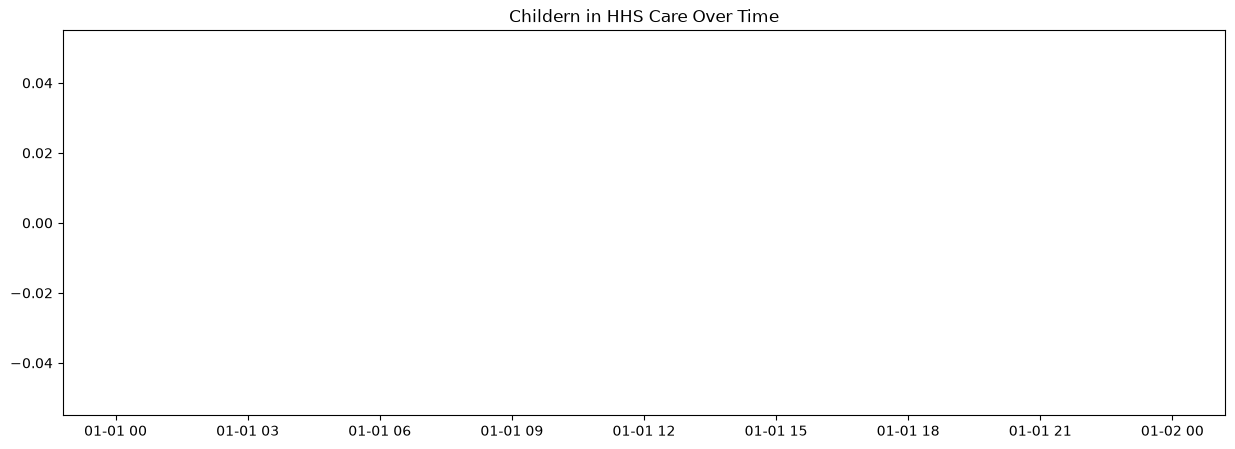

In [17]:
plt.figure(figsize=(15,5))
plt.plot(df["Children in HHS Care"])
plt.title("Childern in HHS Care Over Time")
plt.show()

In [16]:
df["Children in HHS Care"] = pd.to_numeric(
    df["Children in HHS Care"],
    errors="coerce"
)